In [ ]:
### Importing libraries

# 1. Standard Library imports
import gc
import glob
import re
import time
import warnings
from pathlib import Path

# 2. Third-party libraries (Data Science & Geospatial)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

# Correcting Matplotlib specific sub-module imports
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.lines as mlines
import matplotlib.image as mpimg
from matplotlib.ticker import FormatStrFormatter
from matplotlib import rc, colors

# 3. Scikit-Learn (Preprocessing & Metrics)
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# 4. Scikit-Learn (Models/Classifiers)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Settings
warnings.filterwarnings("ignore")
rc('font', family='Times New Roman')

models = {
    'CART': DecisionTreeClassifier(random_state=2025),
    'KNN': KNeighborsClassifier(),
    'MLP': MLPClassifier(random_state=2025),
    'RF': RandomForestClassifier(random_state=2025),
    'SGD': SGDClassifier(random_state=2025),
    'SVM_linear': LinearSVC(random_state=2025),
    'SVM_rbf': SVC(random_state=2025)
}

In [5]:
### Paths
base_path = Path().parent
datasets_path = base_path/ "Datasets"
images_path = base_path/ "Imagery"
results_path = base_path/ "Results"
(results_path / "PNG").mkdir(parents=True, exist_ok=True)
(results_path / "TIFF").mkdir(parents=True, exist_ok=True)

S2_imagery = images_path / "S2"
PS_imagery = images_path / "PS"
S2_images = glob.glob(str(S2_imagery / "*.tif"))
PS_images = glob.glob(str(PS_imagery / "*.tif"))

df_s2train = pd.read_csv(datasets_path / 'S2_Training.csv').dropna()
df_s2val =  pd.read_csv(datasets_path /'S2_Validation.csv').dropna()

df_psstrain = pd.read_csv(datasets_path /'PS_Training.csv').dropna()
df_pssval =  pd.read_csv(datasets_path /'PS_Validation.csv').dropna()

In [6]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, models, imagery, apply_model_on_image=True, condition_label=None):
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    # K-Fold setup for robust variability estimates
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=2025)
    kappa_scorer = make_scorer(cohen_kappa_score)

    filename = Path(imagery).stem if imagery is not None else "dataset"
    if condition_label is not None:
        name = str(condition_label)
    else:
        sat_prefix = "S2" if filename.upper().startswith("S2") else ("PS" if filename.upper().startswith("PS") else "IMG")
        condition_idx = 1 if X_train.shape[1] <= 12 else 2
        name = f"{sat_prefix}_{condition_idx}"

    image_features = None
    meta = None

    if apply_model_on_image:
        # Load image only when explicit image classification is requested
        with rasterio.open(imagery) as src:
            image = src.read()
            meta = src.meta

        img = (image / 10000 * 255 * 1.4).astype(np.uint8)
        pixels = meta['height'] * meta['width']
        #print(pixels, ' pixels')

        # Save original image
        #plt.imshow(np.dstack((img[2], img[1], img[0])))
        #plt.axis('off')
        plt.savefig(results_path / f'original_{filename}.png', bbox_inches='tight', dpi=600, pad_inches=0)

        # Reshape image
        image_reshaped = image.reshape(image.shape[0], -1).T

        # Band selection based on satellite type
        if filename[:2] == 'S2' and X_train.shape[1] == 12:
            image_reshaped = image_reshaped[:, [0, 1, 2, 3, 10, 11, 12, 13, 20, 21, 22, 23]]
        elif filename[:2] == 'PS' and X_train.shape[1] == 12:
            image_reshaped = image_reshaped[:, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]]

        # Imputation
        imputer = SimpleImputer(strategy='mean')
        image_imputed = imputer.fit_transform(image_reshaped)

        # Normalize only necessary part
        image_features = scaler.transform(image_imputed)

        # Free memory
        del image, img, image_reshaped, image_imputed
        gc.collect()
    else:
        print('apply_model_on_image=False: skipping image reading and classification.')

    # Train and evaluate models
    params = []
    results = []
    for model_name, model in models.items():
        # K-Fold variability on training data
        cv_acc_scores = cross_val_score(model, X_train_norm, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
        accuracy_std = round(float(np.std(cv_acc_scores)), 6)

        cv_kappa_scores = cross_val_score(model, X_train_norm, y_train, cv=kfold, scoring=kappa_scorer, n_jobs=-1)
        kappa_std = round(float(np.std(cv_kappa_scores)), 6)

        # Training
        training_times = []
        for _ in range(3):
            start_time = time.time()
            model.fit(X_train_norm, y_train)
            training_times.append(time.time() - start_time)
        training_time = float(np.mean(training_times))
        training_time_std = round(float(np.std(training_times)), 6)

        validation_times = []
        for _ in range(3):
            start_time = time.time()
            y_pred = model.predict(X_test_norm)
            validation_times.append(time.time() - start_time)
        validation_time = float(np.mean(validation_times))
        validation_time_std = round(float(np.std(validation_times)), 6)

        classification_time = np.nan
        classification_time_std = np.nan
        if apply_model_on_image:
            classification_times = []
            for _ in range(3):
                start_time = time.time()
                prediction = model.predict(image_features)
                classification_times.append(time.time() - start_time)
            classification_time = float(np.mean(classification_times))
            classification_time_std = round(float(np.std(classification_times)), 6)

        # Metrics
        accuracy = round(accuracy_score(y_test, y_pred), 6)
        kappa = round(cohen_kappa_score(y_test, y_pred), 6)
        print(f"{model_name} - Imagery: {filename}\n"
              f"Accuracy: {accuracy}\n"
              f"Accuracy Std (KFold): {accuracy_std}\n"
              f"Kappa: {kappa}\n"
              f"Kappa Std (KFold): {kappa_std}\n"
              f"Training Time: {round(training_time, 6)} seconds\n"
              f"Training Time Std: {training_time_std} seconds\n"
              f"Validation Time: {round(validation_time, 6)} seconds\n"
              f"Validation Time Std: {validation_time_std} seconds\n"
              f"Classification Time: {round(classification_time, 6) if apply_model_on_image else 'Skipped'} seconds\n"
              f"Classification Time Std: {classification_time_std if apply_model_on_image else 'Skipped'} seconds")
        print(pd.DataFrame(confusion_matrix(y_test, y_pred)))
        print('-' * 40)

        params.append(model.get_params(deep=True))
        results.append([
            name,
            model_name,
            accuracy,
            accuracy_std,
            kappa,
            kappa_std,
            round(training_time, 6),
            training_time_std,
            round(validation_time, 6),
            validation_time_std,
            round(classification_time, 6) if apply_model_on_image else np.nan,
            classification_time_std
        ])

        if apply_model_on_image:
            # Reshape prediction and save
            prediction_reshaped = prediction.reshape(meta['height'], meta['width'])

            plt.figure(figsize=(16, 16))
            #plt.imshow(prediction_reshaped, cmap=colors.ListedColormap(['red', 'green', 'white']))
            #plt.axis('off')
            plt.savefig(results_path / 'PNG' / f"{model_name}_result_{filename}_{X_train.shape[1]}bands.png",
                        bbox_inches='tight', dpi=600, pad_inches=0)

            # Save as TIFF
            meta.update(count=1)
            with rasterio.open(results_path / 'TIFF' / f"{model_name}_result_{filename}_{X_train.shape[1]}bands.tif", "w", **meta) as dest:
                dest.write(prediction_reshaped, 1)

    # Create results DataFrame
    results_df = pd.DataFrame(
        results,
        columns=[
            "Imagery",
            "Models",
            "OA",
            "OA Std (KFold)",
            "Kappa",
            "Kappa Std (KFold)",
            "Training Time (s)",
            "Training Time Std (s)",
            "Validation Time (s)",
            "Validation Time Std (s)",
            "Classification Time (s)",
            "Classification Time Std (s)"
        ]
    )

    return params, results_df

In [7]:
def run_experiment_S2_4b(apply_model_on_image=True, save_excel=True):
    bands_s2 = [
        'B2_0', 'B3_0', 'B4_0', 'B8_0',
        'B2_1', 'B3_1', 'B4_1', 'B8_1',
        'B2_2', 'B3_2', 'B4_2', 'B8_2'
    ]

    X, y = df_s2train[bands_s2], df_s2train['Class']
    X2, y2 = df_s2val[bands_s2], df_s2val['Class']

    params, results = train_and_evaluate_model(
        X, X2, y, y2, models, S2_images[0], apply_model_on_image=apply_model_on_image, condition_label='S2_1'
    )

    if save_excel:
        results.to_excel(results_path / 'S2_4b.xlsx', index=False)

    return params, results


def run_experiment_S2_Allb(apply_model_on_image=True, save_excel=True):
    bands_s2 = [
        'B2_0', 'B3_0', 'B4_0', 'B5_0', 'B6_0', 'B7_0', 'B8_0', 'B8A_0', 'B11_0', 'B12_0',
        'B2_1', 'B3_1', 'B4_1', 'B5_1', 'B6_1', 'B7_1', 'B8_1', 'B8A_1', 'B11_1', 'B12_1',
        'B2_2', 'B3_2', 'B4_2', 'B5_2', 'B6_2', 'B7_2', 'B8_2', 'B8A_2', 'B11_2', 'B12_2'
    ]

    X, y = df_s2train[bands_s2], df_s2train['Class']
    X2, y2 = df_s2val[bands_s2], df_s2val['Class']

    params, results = train_and_evaluate_model(
        X, X2, y, y2, models, S2_images[0], apply_model_on_image=apply_model_on_image, condition_label='S2_2'
    )

    if save_excel:
        results.to_excel(results_path / 'S2_Allb.xlsx', index=False)

    return params, results


def run_experiment_PS_4b(apply_model_on_image=False, save_excel=True):
    bands_pss = [
        'B2_0', 'B4_0', 'B6_0', 'B8_0',
        'B2_1', 'B4_1', 'B6_1', 'B8_1',
        'B2_2', 'B4_2', 'B6_2', 'B8_2'
    ]

    X, y = df_psstrain[bands_pss], df_psstrain['Class']
    X2, y2 = df_pssval[bands_pss], df_pssval['Class']

    params, results = train_and_evaluate_model(
        X, X2, y, y2, models, PS_images[0], apply_model_on_image=apply_model_on_image, condition_label='PS_1'
    )

    if save_excel:
        results.to_excel(results_path / 'PS_4b.xlsx', index=False)

    return params, results


def run_experiment_PS_Allb(apply_model_on_image=True, save_excel=True):
    bands_pss = [
        'B1_0', 'B2_0', 'B3_0', 'B4_0', 'B5_0', 'B6_0', 'B7_0', 'B8_0',
        'B1_1', 'B2_1', 'B3_1', 'B4_1', 'B5_1', 'B6_1', 'B7_1', 'B8_1',
        'B1_2', 'B2_2', 'B3_2', 'B4_2', 'B5_2', 'B6_2', 'B7_2', 'B8_2'
    ]

    X, y = df_psstrain[bands_pss], df_psstrain['Class']
    X2, y2 = df_pssval[bands_pss], df_pssval['Class']

    params, results = train_and_evaluate_model(
        X, X2, y, y2, models, PS_images[0], apply_model_on_image=apply_model_on_image, condition_label='PS_2'
    )

    if save_excel:
        results.to_excel(results_path / 'PS_Allb.xlsx', index=False)

    return params, results

In [ ]:
experiment_queue = {
    'S2_4b': run_experiment_S2_4b,
    'S2_Allb': run_experiment_S2_Allb,
    'PS_4b': run_experiment_PS_4b,
    'PS_Allb': run_experiment_PS_Allb,
}

# Choose which experiments to run and whether to apply the model on the image for each experiment.
selected_experiments = [
    {'name': 'S2_4b', 'apply_model_on_image': True},
    {'name': 'S2_Allb', 'apply_model_on_image': True},
    {'name': 'PS_4b', 'apply_model_on_image': True},
    {'name': 'PS_Allb', 'apply_model_on_image': True},
]

selected_results = []
for item in selected_experiments:
    name = item['name']
    apply_flag = item.get('apply_model_on_image', True)


    params_i, results_i = experiment_queue[name](
        apply_model_on_image=apply_flag,
        save_excel=True,
    )
    globals()[name] = results_i
    globals()[f'params_{name}'] = params_i
    selected_results.append(results_i)

results = pd.concat(selected_results, ignore_index=True) if selected_results else pd.DataFrame()
results.to_excel(results_path / 'model_results.xlsx', index=False)

Figures

In [8]:
ALG_COLORS = {
    "CART": "blue",
    "KNN": "black",
    "MLP": "gold",
    "RF": "green",
    "SGDC": "red",
    "LinearSVC": "saddlebrown",
    "SVC_rbf": "darkviolet",
}
PREFERRED_ALG_ORDER = ["CART", "KNN", "MLP", "RF", "SGDC", "LinearSVC", "SVC_rbf"]
IMAGERY_MARKERS = {"S2": "^", "PS": "o"}

def pick_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col

    normalized_map = {
        "".join(ch for ch in str(col).lower() if ch.isalnum()): col
        for col in df.columns
    }
    for col in candidates:
        normalized = "".join(ch for ch in str(col).lower() if ch.isalnum())
        if normalized in normalized_map:
            return normalized_map[normalized]

    raise ValueError(
        f"Nao encontrei a coluna de {label}. Candidatas: {candidates}. Colunas disponiveis: {list(df.columns)}"
    )

def extract_condition_level(imagery_name):
    text = str(imagery_name).strip()
    match = re.search(r"_(\d+)\b", text)
    return int(match.group(1)) if match else None

def extract_band_count(imagery_name):
    text = str(imagery_name)
    match = re.search(r"(\d+)\s*bands?", text, flags=re.IGNORECASE)
    if match is None:
        match = re.search(r"_(\d+)bands?", text, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

def normalize_model_name(model_name):
    return str(model_name).strip()

def infer_imagery_set(imagery_name):
    text = str(imagery_name).upper()
    if "S2" in text:
        return "S2"
    if "PS" in text:
        return "PS"
    return "OTHER"

def pct_diff(high_values, low_values):
    denom = np.where(np.abs(low_values) < 1e-12, np.nan, low_values)
    return ((high_values - low_values) / denom) * 100.0

def order_models(model_values):
    model_values = [str(m) for m in model_values]
    preferred = [m for m in PREFERRED_ALG_ORDER if m in model_values]
    remaining = sorted([m for m in model_values if m not in preferred])
    return preferred + remaining

def pick_low_high_imagery(condition_names):
    condition_names = [str(x).strip() for x in condition_names]

    level_map = {name: extract_condition_level(name) for name in condition_names}
    low_candidates = [name for name in condition_names if level_map.get(name) == 1]
    high_candidates = [name for name in condition_names if level_map.get(name) == 2]

    if low_candidates and high_candidates:
        return low_candidates[0], high_candidates[0]

    known_levels = [level_map[name] for name in condition_names if level_map.get(name) is not None]
    if known_levels:
        min_level = min(known_levels)
        max_level = max(known_levels)
        low = next((name for name in condition_names if level_map.get(name) == min_level), None)
        high = next((name for name in condition_names if level_map.get(name) == max_level), None)
        if low is not None and high is not None and low != high:
            return low, high

    band_map = {name: extract_band_count(name) for name in condition_names}
    with_band = [name for name in condition_names if band_map.get(name) is not None]
    if len(with_band) >= 2:
        low = min(with_band, key=lambda name: band_map[name])
        high = max(with_band, key=lambda name: band_map[name])
        if low != high:
            return low, high

    return None, None

def load_results_dataframe(results_file):
    if not Path(results_file).exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {results_file}")
    return pd.read_excel(results_file)

def resolve_time_columns(df_results):
    imagery_col = pick_column(df_results, ["Imagery", "imagery", "Condition", "Dataset", "Image"], "imagery")
    model_col = pick_column(df_results, ["Models", "Model", "Algorithm", "Classifier", "Classificador"], "modelo")
    ct_col = pick_column(
        df_results,
        [
            "Classification Time (s)",
            "Classification Time",
            "Classification_Time",
            "Class Time (s)",
            "Class Time",
            "CT",
        ],
        "classification time",
    )
    tt_col = pick_column(
        df_results,
        [
            "Training Time (s)",
            "Training Time",
            "Training_Time",
            "Train Time (s)",
            "Train Time",
            "TT",
        ],
        "training time",
    )
    return imagery_col, model_col, ct_col, tt_col

def build_time_metrics_dataframe(df_results):
    imagery_col, model_col, ct_col, tt_col = resolve_time_columns(df_results)
    df_metrics = df_results[[imagery_col, model_col, ct_col, tt_col]].copy()
    df_metrics[ct_col] = pd.to_numeric(df_metrics[ct_col], errors="coerce")
    df_metrics[tt_col] = pd.to_numeric(df_metrics[tt_col], errors="coerce")
    df_metrics = df_metrics.dropna(subset=[imagery_col, model_col, ct_col, tt_col])
    df_metrics[model_col] = df_metrics[model_col].map(normalize_model_name)
    df_metrics[imagery_col] = df_metrics[imagery_col].astype(str).str.strip()
    df_metrics["Image Set"] = df_metrics[imagery_col].map(infer_imagery_set)
    df_metrics = df_metrics[df_metrics["Image Set"].isin(["S2", "PS"])].copy()
    return df_metrics, imagery_col, model_col, ct_col, tt_col

def nested_dict_from_grouped(grouped, imagery_col, model_col, oa_col, ct_col, tt_col):
    data = {}
    for _, row in grouped.iterrows():
        imagery = str(row[imagery_col]).strip()
        model = str(row[model_col]).strip()
        oa = float(row[oa_col])
        ct = float(row[ct_col])
        tt = float(row[tt_col])

        if imagery not in data:
            data[imagery] = {}
        data[imagery][model] = (oa, ct, tt)
    return data

def select_imagery_by_level(imagery_names, target_level):
    level_map = {img: extract_condition_level(img) for img in imagery_names}
    band_map = {img: extract_band_count(img) for img in imagery_names}

    fallback_selection = set()
    for sat in ["S2", "PS"]:
        sat_imgs = [img for img in imagery_names if sat in img.upper()]
        sat_with_band = [img for img in sat_imgs if band_map[img] is not None]
        if sat_with_band:
            if target_level >= 2:
                target_img = max(sat_with_band, key=lambda x: band_map[x])
            else:
                target_img = min(sat_with_band, key=lambda x: band_map[x])
            fallback_selection.add(target_img)

    selected = []
    for img in imagery_names:
        level = level_map.get(img)
        include_img = (level == target_level) if level is not None else (img in fallback_selection)
        if include_img:
            selected.append(img)

    return selected, level_map, band_map

def load_plot_data(results_file):
    df_results = load_results_dataframe(results_file)

    imagery_col = pick_column(df_results, ["Imagery", "imagery", "Condition", "Dataset", "Image"], "imagery")
    model_col = pick_column(df_results, ["Models", "Model", "Algorithm", "Classifier", "Classificador"], "modelo")
    oa_col = pick_column(df_results, ["OA", "Overall Accuracy", "overall_accuracy", "Accuracy"], "OA")
    ct_col = pick_column(
        df_results,
        [
            "Classification Time (s)",
            "Classification Time",
            "Classification_Time",
            "Class Time (s)",
            "Class Time",
            "CT",
        ],
        "classification time",
    )
    tt_col = pick_column(
        df_results,
        [
            "Training Time (s)",
            "Training Time",
            "Training_Time",
            "Train Time (s)",
            "Train Time",
            "TT",
        ],
        "training time",
    )

    df_metrics = df_results[[imagery_col, model_col, oa_col, ct_col, tt_col]].copy()
    df_metrics[oa_col] = pd.to_numeric(df_metrics[oa_col], errors="coerce")
    df_metrics[ct_col] = pd.to_numeric(df_metrics[ct_col], errors="coerce")
    df_metrics[tt_col] = pd.to_numeric(df_metrics[tt_col], errors="coerce").fillna(0.0)
    df_metrics = df_metrics.dropna(subset=[imagery_col, model_col, oa_col, ct_col])
    df_metrics[model_col] = df_metrics[model_col].map(normalize_model_name)

    grouped = (
        df_metrics
        .groupby([imagery_col, model_col], as_index=False, sort=False)[[oa_col, ct_col, tt_col]]
        .mean()
    )

    if grouped.empty:
        raise ValueError("Nenhum dado valido foi carregado do arquivo XLSX.")

    imagery_names = [str(x).strip() for x in grouped[imagery_col].unique()]
    all_data = nested_dict_from_grouped(grouped, imagery_col, model_col, oa_col, ct_col, tt_col)

    all_level2, level_map, band_map = select_imagery_by_level(imagery_names, target_level=2)
    all_level1, _, _ = select_imagery_by_level(imagery_names, target_level=1)

    all_data_level2 = nested_dict_from_grouped(
        grouped[grouped[imagery_col].astype(str).isin(all_level2)],
        imagery_col,
        model_col,
        oa_col,
        ct_col,
        tt_col,
    )
    all_data_level1 = nested_dict_from_grouped(
        grouped[grouped[imagery_col].astype(str).isin(all_level1)],
        imagery_col,
        model_col,
        oa_col,
        ct_col,
        tt_col,
    )

    max_bands_by_type = {}
    for img, band_count in band_map.items():
        imagery_type = "S2" if "S2" in img.upper() else "PS"
        if band_count is not None:
            current_max = max_bands_by_type.get(imagery_type)
            if current_max is None or band_count > current_max:
                max_bands_by_type[imagery_type] = band_count

    return {
        "data_by_mode": {
            "both": all_data,
            "all": all_data_level2,
            "4": all_data_level1,
        },
        "level_map": level_map,
        "band_map": band_map,
        "max_bands_by_type": max_bands_by_type,
    }

In [9]:
RESULTS_FILE = results_path / "model_results.xlsx"
plot_data = load_plot_data(RESULTS_FILE)

In [10]:
def is_all_bands_imagery(imagery_name, level_map, band_map, max_bands_by_type):
    level = level_map.get(imagery_name)
    if level is not None:
        return level >= 2

    text_lower = str(imagery_name).lower()
    if "all" in text_lower:
        return True

    imagery_type = "S2" if "S2" in str(imagery_name).upper() else "PS"
    band_count = band_map.get(imagery_name)
    max_band_count = max_bands_by_type.get(imagery_type)
    return (
        band_count is not None
        and max_band_count is not None
        and band_count == max_band_count
    )

def plot_scatter_from_mode(
    plot_data,
    mode="both",
    output_name="FigRes.png",
    marker_scale_factor=1.5,
    min_point_size=18,
    save_dpi=600,
    show_xlabel=True,
    bands=True
 ):
    if mode not in {"both", "all", "4"}:
        raise ValueError("mode deve ser 'both', 'all' ou '4'.")

    data = plot_data["data_by_mode"].get(mode, {})
    if not data:
        raise ValueError(f"Nenhum dado encontrado para o modo '{mode}'.")

    plt.rcParams["font.family"] = "serif"
    plt.figure(figsize=(10, 6))

    alg_legend = {}
    imagery_legend = {}

    level_map = plot_data["level_map"]
    band_map = plot_data["band_map"]
    max_bands_by_type = plot_data["max_bands_by_type"]

    for imagery, alg_data in data.items():
        imagery_type = "S2" if "S2" in imagery.upper() else "PS"
        marker = IMAGERY_MARKERS[imagery_type]

        if mode == "all":
            is_high_band = True
        elif mode == "4":
            is_high_band = False
        else:
            is_high_band = is_all_bands_imagery(imagery, level_map, band_map, max_bands_by_type)

        # Desenha primeiro os maiores e depois os menores para os pequenos ficarem visiveis por cima.
        plot_items = []
        for alg, (oa, classification_time, training_time) in alg_data.items():
            point_size = (training_time * 100 if training_time < 0.5 else training_time * 35) * marker_scale_factor
            point_size = max(min_point_size, point_size)
            plot_items.append((alg, oa, classification_time, point_size))

        plot_items.sort(key=lambda item: item[3], reverse=True)

        for alg, oa, classification_time, point_size in plot_items:
            color = ALG_COLORS.get(alg, "gray")

            if is_high_band:
                plt.scatter(
                    classification_time,
                    oa,
                    color=color,
                    marker=marker,
                    s=point_size,
                    edgecolor=color,
                    linewidth=0.8,
                    zorder=2,
                )
            else:
                # Mantem o destaque de baixa banda com preenchimento sutil.
                plt.scatter(
                    classification_time,
                    oa,
                    facecolors=mcolors.to_rgba(color, alpha=0.22),
                    edgecolor=color,
                    marker=marker,
                    s=point_size,
                    linewidth=0.8,
                    zorder=2,
                )

            if alg not in alg_legend:
                alg_legend[alg] = plt.Line2D([0], [0], color=color, marker="o", linestyle="None")
            if imagery_type not in imagery_legend:
                imagery_legend[imagery_type] = plt.Line2D([0], [0], color="black", marker=marker, linestyle="None")

    alg_legend_labels = [alg for alg in PREFERRED_ALG_ORDER if alg in alg_legend] + [alg for alg in alg_legend if alg not in PREFERRED_ALG_ORDER]
    alg_legend_handles = [alg_legend[alg] for alg in alg_legend_labels]

    imagery_legend_handles = list(imagery_legend.values())
    imagery_legend_labels = ["Sentinel-2", "PlanetScope"]

    bands_legend = [
        mlines.Line2D([0], [0], color="black", marker="s", markerfacecolor="none", linestyle="None", markersize=8, label="4 bands"),
        mlines.Line2D([0], [0], color="black", marker="s", markerfacecolor="black", linestyle="None", markersize=8, label="All bands"),
    ]

    size_legend_values = [0.01, 17.16, 34.32]
    size_legend_markers = [3.5, 12.6, 23.8]
    size_legend = [
        mlines.Line2D(
            [0],
            [0],
            color="gray",
            marker="o",
            linestyle="None",
            markersize=marker_size * marker_scale_factor,
            markerfacecolor="gray",
            markeredgecolor="gray",
            label=f"{value:.2f}",
        )
        for marker_size, value in zip(size_legend_markers, size_legend_values)
    ]

    title_to_first_gap = 0.0
    gap_1_to_2 = 0.8
    gap_2_to_3 = 2.8

    training_legend_anchor_x = 1.2
    training_legend_anchor_y = 0.3
    third_item_offset_y = 0.035 + 0.02 * gap_2_to_3

    legend1 = plt.legend(
        imagery_legend_handles,
        imagery_legend_labels,
        title="Imagery",
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1, 1),
        frameon=False,
    )
    legend2 = plt.legend(
        alg_legend_handles,
        alg_legend_labels,
        title="Algorithm",
        fontsize=8,
        loc="lower left",
        bbox_to_anchor=(1, 0.53),
        frameon=False,
    )
    plt.gca().add_artist(legend1)

    legend3_top = plt.legend(
        handles=size_legend[:2],
        title="Training Time (s)",
        fontsize=8,
        loc="lower right",
        bbox_to_anchor=(training_legend_anchor_x - 0.008, training_legend_anchor_y),
        frameon=False,
        handlelength=1.0,
        handletextpad=2.8,
        labelspacing=gap_1_to_2,
        handleheight=3.5,
    )
    legend3_top._legend_box.sep = title_to_first_gap

    legend3_bottom = plt.legend(
        handles=[size_legend[2]],
        fontsize=8,
        loc="lower right",
        bbox_to_anchor=(training_legend_anchor_x - 0.0285, training_legend_anchor_y - third_item_offset_y),
        frameon=False,
        handlelength=1.0,
        handletextpad=3.5,
    )

    plt.gca().add_artist(legend2)
    plt.gca().add_artist(legend3_top)

    if bands == True:
        plt.legend(
            handles=bands_legend,
            title="Number of bands",
            fontsize=8,
            loc="lower left",
            bbox_to_anchor=(1, 0.00),
            frameon=False,
        )
        plt.gca().add_artist(legend3_bottom)

    plt.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.xscale("log")
    if show_xlabel:
        plt.xlabel("Classification Time (s)")
    plt.ylabel("Overall Accuracy (OA)")
    plt.tight_layout()
    plt.savefig(output_name, dpi=save_dpi)
    plt.show()

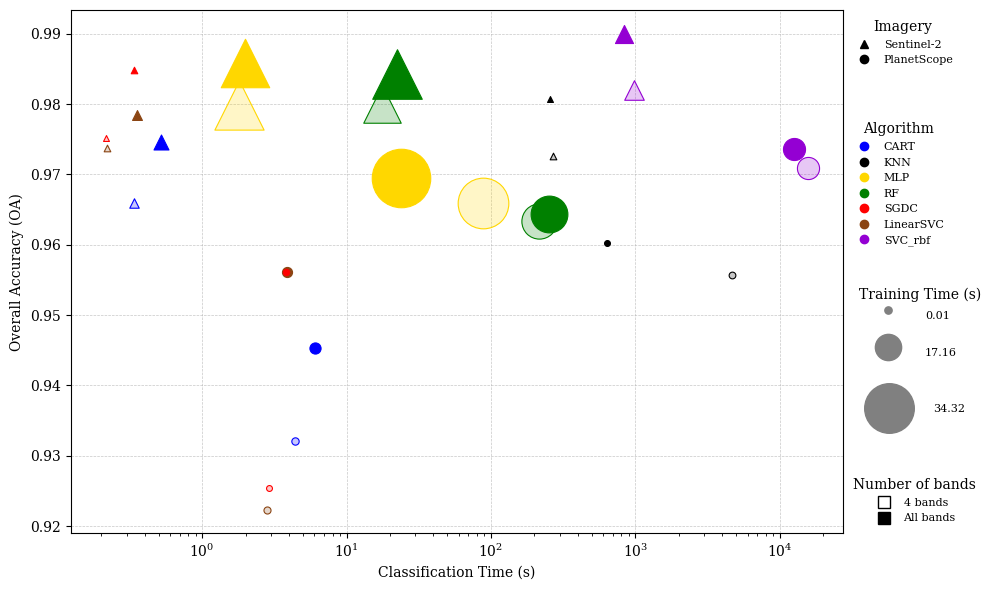

In [11]:
plot_scatter_from_mode(plot_data, mode="both", output_name="FigRes.png",bands=True)

Arquivo carregado: Results\model_results.xlsx


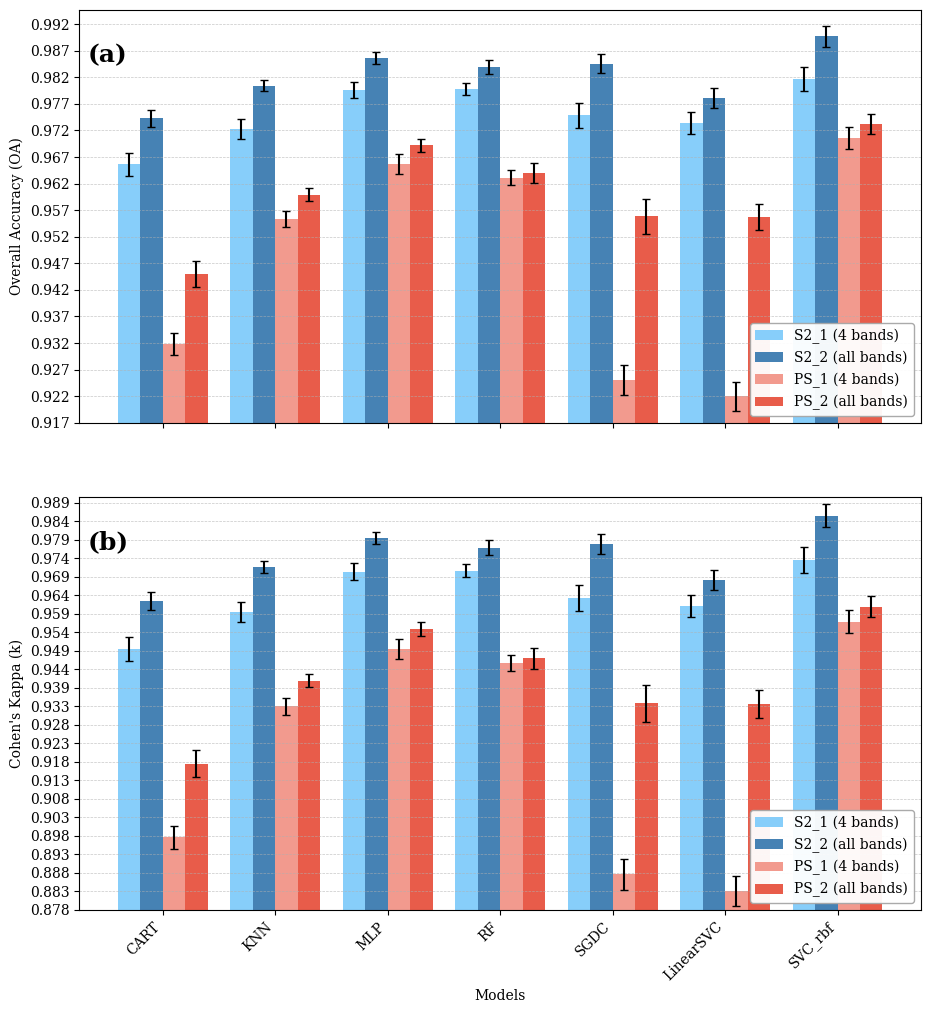

Figura salva: fig_appendix_OA_k_S2vsPS_ML4RS.png


In [15]:
df_results = load_results_dataframe(RESULTS_FILE)
print(f"Arquivo carregado: {RESULTS_FILE}")

imagery_col_local = pick_column(
    df_results,
    ["Imagery", "imagery", "Condition", "Dataset", "Image"],
    "imagery",
)
model_col_local = pick_column(
    df_results,
    ["Models", "Model", "Algorithm", "Classifier", "Classificador"],
    "modelo",
)

df_results = df_results.rename(columns={imagery_col_local: "Imagery", model_col_local: "Models"})
df_results["Models"] = df_results["Models"].map(normalize_model_name)
PREFERRED_MODEL_ORDER = ["CART", "KNN", "MLP", "RF", "SGDC", "LinearSVC", "SVC_rbf"]

def get_band_count(cond):
    cond_str = str(cond)
    match = re.search(r"_(\d+)bands?", cond_str, flags=re.IGNORECASE)
    if match is None:
        match = re.search(r"(\d+)\s*bands?", cond_str, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

def pick_conditions(df_in, sat_prefix):
    conds = [c for c in df_in["Imagery"].astype(str).unique() if c.upper().startswith(sat_prefix)]
    if len(conds) < 2:
        return None, None
    conds_sorted = sorted(conds, key=lambda c: get_band_count(c) if get_band_count(c) is not None else 999)
    return conds_sorted[0], conds_sorted[-1]

def get_metric_std_col(df_in, metric_std_candidates):
    return next((c for c in metric_std_candidates if c in df_in.columns), None)

def prepare_metric_frames(df_in, metric_col, std_col):
    if metric_col not in df_in.columns:
        raise ValueError(f"Coluna obrigatoria nao encontrada: {metric_col}")
    if std_col is None:
        raise ValueError(f"Nao encontrei coluna de desvio padrao para {metric_col}.")

    s2_low, s2_high = pick_conditions(df_in, "S2")
    ps_low, ps_high = pick_conditions(df_in, "PS")
    if None in [s2_low, s2_high, ps_low, ps_high]:
        raise ValueError("Nao foi possivel identificar duas condicoes para S2 e PS.")

    def get_cond_df(cond_name):
        out = df_in[df_in["Imagery"].astype(str) == cond_name][["Models", metric_col, std_col]].copy()
        return out.rename(columns={metric_col: "value", std_col: "std"}).set_index("Models")

    df_s2_low = get_cond_df(s2_low)
    df_s2_high = get_cond_df(s2_high)
    df_ps_low = get_cond_df(ps_low)
    df_ps_high = get_cond_df(ps_high)

    intersection_models = set(df_s2_low.index) & set(df_s2_high.index) & set(df_ps_low.index) & set(df_ps_high.index)
    common_models = [m for m in PREFERRED_MODEL_ORDER if m in intersection_models]
    extra_models = sorted([m for m in intersection_models if m not in common_models])
    common_models = common_models + extra_models

    if not common_models:
        raise ValueError(f"Nao ha modelos em comum para {metric_col}.")

    return {
        "models": common_models,
        "s2_low": df_s2_low.loc[common_models],
        "s2_high": df_s2_high.loc[common_models],
        "ps_low": df_ps_low.loc[common_models],
        "ps_high": df_ps_high.loc[common_models],
    }

oa_std_candidates = ["OA Std (KFold)", "OA Std", "OA_std", "Accuracy Std (KFold)", "accuracy_std"]
kappa_std_candidates = ["Kappa Std (KFold)", "Kappa Std", "Kappa_std", "kappa_std"]

oa_std_col = get_metric_std_col(df_results, oa_std_candidates)
kappa_std_col = get_metric_std_col(df_results, kappa_std_candidates)

oa_data = prepare_metric_frames(df_results, metric_col="OA", std_col=oa_std_col)
kappa_data = prepare_metric_frames(df_results, metric_col="Kappa", std_col=kappa_std_col)

final_models = [m for m in oa_data["models"] if m in set(kappa_data["models"])]
if not final_models:
    raise ValueError("Nao ha modelos em comum entre OA e Kappa para montar a figura combinada.")

for key in ["s2_low", "s2_high", "ps_low", "ps_high"]:
    oa_data[key] = oa_data[key].loc[final_models]
    kappa_data[key] = kappa_data[key].loc[final_models]

x = np.arange(len(final_models))
w = 0.2

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9.4, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.18},
)
fig.subplots_adjust(left=0.09, right=0.985, top=0.985, bottom=0.085, hspace=0.18)

def plot_metric_panel(ax, data, ylabel):
    y_s2_low = data["s2_low"]["value"].astype(float).values
    e_s2_low = data["s2_low"]["std"].fillna(0).astype(float).values
    y_s2_high = data["s2_high"]["value"].astype(float).values
    e_s2_high = data["s2_high"]["std"].fillna(0).astype(float).values
    y_ps_low = data["ps_low"]["value"].astype(float).values
    e_ps_low = data["ps_low"]["std"].fillna(0).astype(float).values
    y_ps_high = data["ps_high"]["value"].astype(float).values
    e_ps_high = data["ps_high"]["std"].fillna(0).astype(float).values

    ax.bar(x - 1.5 * w, y_s2_low, w, yerr=e_s2_low, color="lightskyblue", capsize=3, linewidth=0, label="S2_1 (4 bands)")
    ax.bar(x - 0.5 * w, y_s2_high, w, yerr=e_s2_high, color="steelblue", capsize=3, linewidth=0, label="S2_2 (all bands)")
    ax.bar(x + 0.5 * w, y_ps_low, w, yerr=e_ps_low, color="#F29A8E", capsize=3, linewidth=0, label="PS_1 (4 bands)")
    ax.bar(x + 1.5 * w, y_ps_high, w, yerr=e_ps_high, color="#E85C4A", capsize=3, linewidth=0, label="PS_2 (all bands)")

    all_vals = np.concatenate([y_s2_low, y_s2_high, y_ps_low, y_ps_high])
    y_min = max(0.0, float(np.min(all_vals)) - 0.005)
    y_max = min(1.0, float(np.max(all_vals)) + 0.005)
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(np.arange(y_min, y_max + 0.0001, 0.005))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="0.65", framealpha=0.95)

plot_metric_panel(ax1, oa_data, ylabel="Overall Accuracy (OA)")
plot_metric_panel(ax2, kappa_data, ylabel="Cohen's Kappa (k)")

ax1.text(0.01, 0.92, "(a)", transform=ax1.transAxes, fontsize=18, fontweight="bold", va="top")
ax2.text(0.01, 0.92, "(b)", transform=ax2.transAxes, fontsize=18, fontweight="bold", va="top")

ax1.tick_params(axis="x", which="both", labelbottom=False)
ax2.set_xticks(x)
ax2.set_xticklabels(final_models, rotation=45, ha="right")
ax2.set_xlabel("Models")

output_name = "fig_appendix_OA_k_S2vsPS_ML4RS"
plt.savefig(f"{output_name}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
plt.show()
print(f"Figura salva: {output_name}.png")

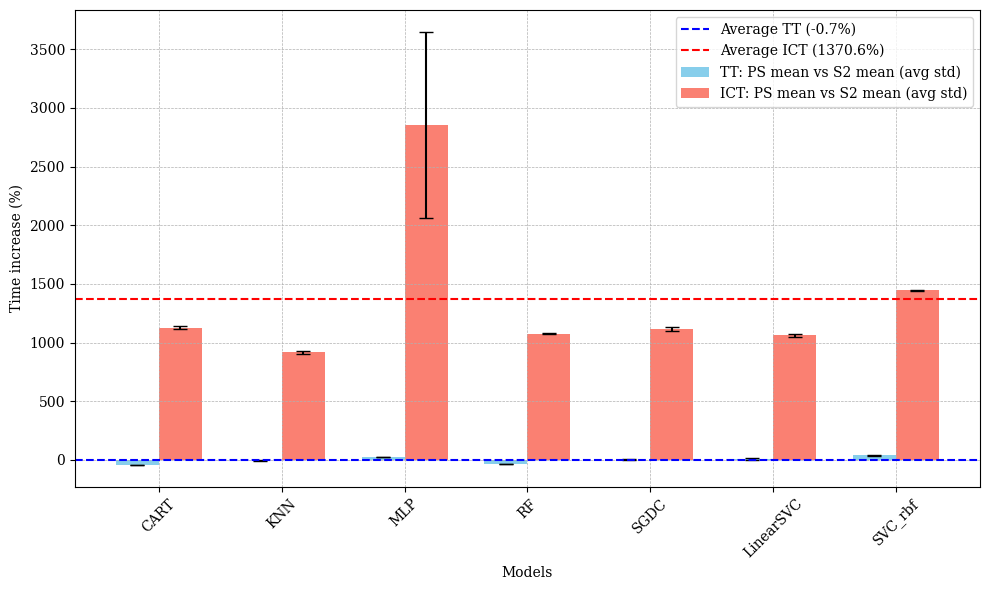

Comparacao usada: PS_mean (PS_1+PS_2) vs S2_mean (S2_1+S2_2)
Coluna de std TT usada do arquivo: Training Time Std (s)
Coluna de std ICT usada do arquivo: Classification Time Std (s)
       Model  Dif tt (%)  tt_std_pct   Dif ct (%)  ct_std_pct
0       CART  -43.054352    2.025919  1128.457170   14.769702
1        KNN   -2.188842    4.175953   915.605654   10.773073
2        MLP   25.532040    0.753114  2854.382239  794.886427
3         RF  -32.801521    1.647736  1075.938045    5.553854
4       SGDC    2.448466    6.459549  1115.160870   16.252628
5  LinearSVC    7.239129    5.928662  1060.723209   14.513889
6    SVC_rbf   37.982515    2.318878  1444.175922    7.933047


In [16]:
# Impacto da mudanca de satelite: PS_mean vs S2_mean, com erro = media dos std
import numpy as np
import matplotlib.pyplot as plt

if "RESULTS_FILE" not in globals():
    raise ValueError("Execute a celula 9 primeiro para carregar a tabela de resultados.")

df_results_std = load_results_dataframe(RESULTS_FILE)
df_sat, imagery_col, model_col, ct_col, tt_col = build_time_metrics_dataframe(df_results_std)

tt_std_candidates = [
    "Training Time Std (s)",
    "Training Time Std",
    "TT Std (s)",
    "TT Std",
    "Std TT",
    "TT_std",
]
ct_std_candidates = [
    "Classification Time Std (s)",
    "Classification Time Std",
    "ICT Std (s)",
    "ICT Std",
    "CT Std (s)",
    "CT Std",
    "Std ICT",
    "Std CT",
    "CT_std",
]

tt_std_col = next((c for c in tt_std_candidates if c in df_results_std.columns), None)
ct_std_col = next((c for c in ct_std_candidates if c in df_results_std.columns), None)

if tt_std_col is None:
    df_sat["tt_std_raw"] = np.nan
else:
    df_sat["tt_std_raw"] = pd.to_numeric(df_results_std.loc[df_sat.index, tt_std_col], errors="coerce")

if ct_std_col is None:
    df_sat["ct_std_raw"] = np.nan
else:
    df_sat["ct_std_raw"] = pd.to_numeric(df_results_std.loc[df_sat.index, ct_std_col], errors="coerce")

set_model_means = (
    df_sat
    .groupby(["Image Set", model_col], as_index=False)[[tt_col, ct_col]]
    .mean()
)

if tt_std_col is not None:
    tt_std_by_set = df_sat.groupby(["Image Set", model_col], as_index=False)["tt_std_raw"].mean()
    tt_std_by_set = tt_std_by_set.rename(columns={"tt_std_raw": "tt_std_set"})
else:
    tt_std_by_set = df_sat.groupby(["Image Set", model_col], as_index=False)[tt_col].std()
    tt_std_by_set = tt_std_by_set.rename(columns={tt_col: "tt_std_set"})

if ct_std_col is not None:
    ct_std_by_set = df_sat.groupby(["Image Set", model_col], as_index=False)["ct_std_raw"].mean()
    ct_std_by_set = ct_std_by_set.rename(columns={"ct_std_raw": "ct_std_set"})
else:
    ct_std_by_set = df_sat.groupby(["Image Set", model_col], as_index=False)[ct_col].std()
    ct_std_by_set = ct_std_by_set.rename(columns={ct_col: "ct_std_set"})

set_model_stats = set_model_means.merge(tt_std_by_set, on=["Image Set", model_col], how="left")
set_model_stats = set_model_stats.merge(ct_std_by_set, on=["Image Set", model_col], how="left")
set_model_stats[["tt_std_set", "ct_std_set"]] = set_model_stats[["tt_std_set", "ct_std_set"]].fillna(0.0)

s2_stats = set_model_stats[set_model_stats["Image Set"] == "S2"][[model_col, tt_col, ct_col, "tt_std_set", "ct_std_set"]].copy()
ps_stats = set_model_stats[set_model_stats["Image Set"] == "PS"][[model_col, tt_col, ct_col, "tt_std_set", "ct_std_set"]].copy()

sat_merge = s2_stats.merge(ps_stats, on=model_col, suffixes=("_s2", "_ps"))
if sat_merge.empty:
    raise ValueError("Nao foi possivel calcular comparacao PS_mean vs S2_mean para os modelos.")

sat_merge["Dif tt (%)"] = pct_diff(sat_merge[f"{tt_col}_ps"].values, sat_merge[f"{tt_col}_s2"].values)
sat_merge["Dif ct (%)"] = pct_diff(sat_merge[f"{ct_col}_ps"].values, sat_merge[f"{ct_col}_s2"].values)

sat_merge["tt_std_avg"] = (sat_merge["tt_std_set_s2"].astype(float) + sat_merge["tt_std_set_ps"].astype(float)) / 2.0
sat_merge["ct_std_avg"] = (sat_merge["ct_std_set_s2"].astype(float) + sat_merge["ct_std_set_ps"].astype(float)) / 2.0

eps = 1e-12
den_tt = sat_merge[f"{tt_col}_s2"].astype(float).values
den_ct = sat_merge[f"{ct_col}_s2"].astype(float).values
sat_merge["tt_std_pct"] = np.where(np.abs(den_tt) < eps, np.nan, (sat_merge["tt_std_avg"].astype(float).values / np.abs(den_tt)) * 100.0)
sat_merge["ct_std_pct"] = np.where(np.abs(den_ct) < eps, np.nan, (sat_merge["ct_std_avg"].astype(float).values / np.abs(den_ct)) * 100.0)

sat_diff_df = sat_merge[[model_col, "Dif tt (%)", "Dif ct (%)", "tt_std_pct", "ct_std_pct"]].copy()
sat_diff_df = sat_diff_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Dif tt (%)", "Dif ct (%)"])
sat_diff_df = sat_diff_df.rename(columns={model_col: "Model"})

model_order_sat = order_models(sat_diff_df["Model"].unique())
sat_diff_df = sat_diff_df.set_index("Model").loc[model_order_sat].reset_index()

tt_mean_sat = float(sat_diff_df["Dif tt (%)"].mean())
ct_mean_sat = float(sat_diff_df["Dif ct (%)"].mean())

x = np.arange(len(sat_diff_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x - width / 2,
    sat_diff_df["Dif tt (%)"],
    width,
    yerr=sat_diff_df["tt_std_pct"].fillna(0.0),
    label="TT: PS mean vs S2 mean (avg std)",
    color="skyblue",
    capsize=5,
    linewidth=0,
)
ax.bar(
    x + width / 2,
    sat_diff_df["Dif ct (%)"],
    width,
    yerr=sat_diff_df["ct_std_pct"].fillna(0.0),
    label="ICT: PS mean vs S2 mean (avg std)",
    color="salmon",
    capsize=5,
    linewidth=0,
)

ax.axhline(tt_mean_sat, color="blue", linestyle="--", linewidth=1.5, label=f"Average TT ({tt_mean_sat:.1f}%)")
ax.axhline(ct_mean_sat, color="red", linestyle="--", linewidth=1.5, label=f"Average ICT ({ct_mean_sat:.1f}%)")

ax.set_xlabel("Models")
ax.set_xticks(x)
ax.set_xticklabels(sat_diff_df["Model"], rotation=45)
ax.set_ylabel("Time increase (%)")
ax.legend()

plt.tight_layout()
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
plt.savefig("dif_tt_ict_satellite_impact_avg_std.png", dpi=400)
plt.show()

print("Comparacao usada: PS_mean (PS_1+PS_2) vs S2_mean (S2_1+S2_2)")
print(f"Coluna de std TT usada do arquivo: {tt_std_col}")
print(f"Coluna de std ICT usada do arquivo: {ct_std_col}")
print(sat_diff_df[["Model", "Dif tt (%)", "tt_std_pct", "Dif ct (%)", "ct_std_pct"]])

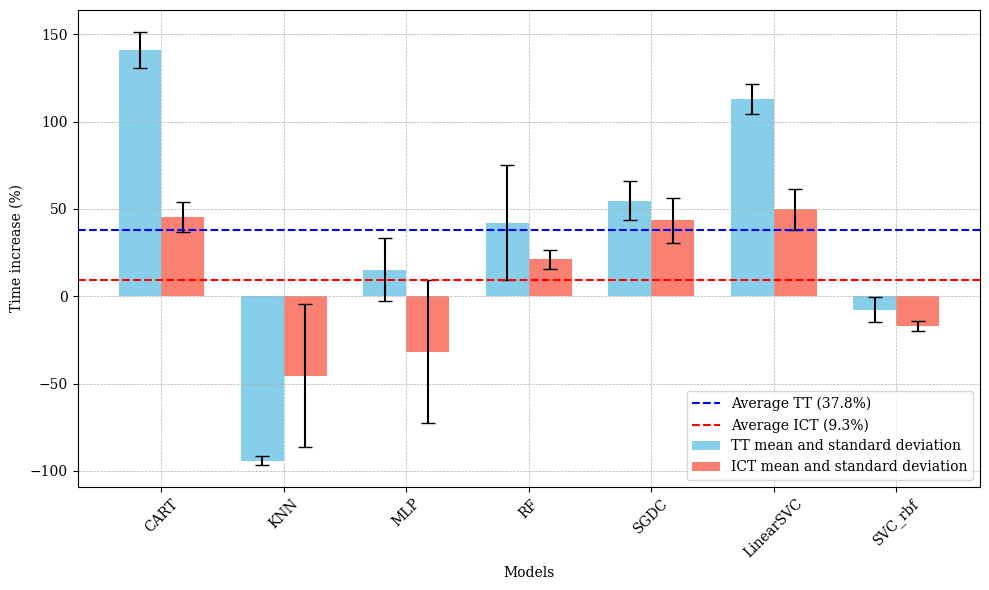

In [17]:
df_local = load_results_dataframe(RESULTS_FILE)
df_metrics_local, imagery_col, model_col, ct_col, tt_col = build_time_metrics_dataframe(df_local)

grouped_local = (
    df_metrics_local
    .groupby(["Image Set", imagery_col, model_col], as_index=False)[[tt_col, ct_col]]
    .mean()
)

rows_band = []
for image_set in ["S2", "PS"]:
    set_df = grouped_local[grouped_local["Image Set"] == image_set].copy()
    cond_names = set_df[imagery_col].unique().tolist()
    low_cond, high_cond = pick_low_high_imagery(cond_names)
    if low_cond is None or high_cond is None:
        continue

    low_df = set_df[set_df[imagery_col] == low_cond][[model_col, tt_col, ct_col]].copy()
    high_df = set_df[set_df[imagery_col] == high_cond][[model_col, tt_col, ct_col]].copy()
    merged = low_df.merge(high_df, on=model_col, suffixes=("_low", "_high"))
    if merged.empty:
        continue

    merged["Dif tt (%)"] = pct_diff(merged[f"{tt_col}_high"].values, merged[f"{tt_col}_low"].values)
    merged["Dif ct (%)"] = pct_diff(merged[f"{ct_col}_high"].values, merged[f"{ct_col}_low"].values)
    merged = merged.replace([np.inf, -np.inf], np.nan).dropna(subset=["Dif tt (%)", "Dif ct (%)"])
    for _, row in merged.iterrows():
        rows_band.append({
            "Image Set": image_set,
            "Model": row[model_col],
            "Dif tt (%)": float(row["Dif tt (%)"]),
            "Dif ct (%)": float(row["Dif ct (%)"]),
        })

if not rows_band:
    raise ValueError("Nao foi possivel calcular diferencas TT/ICT por bandas para S2 e PS.")

diff_df_bands = pd.DataFrame(rows_band)
model_order = order_models(diff_df_bands["Model"].unique())

imgdf_bands = diff_df_bands.groupby("Model")[["Dif tt (%)", "Dif ct (%)"]].agg(["mean", "std", "count"]).reset_index()
imgdf_bands = imgdf_bands.set_index("Model").loc[model_order].reset_index()
imgdf_bands.columns = [
    "Model",
    "tt_mean", "tt_std", "tt_n",
    "ct_mean", "ct_std", "ct_n",
]

imgdf_bands[["tt_std", "ct_std"]] = imgdf_bands[["tt_std", "ct_std"]].fillna(0.0)
imgdf_bands[["tt_n", "ct_n"]] = imgdf_bands[["tt_n", "ct_n"]].fillna(0)

imgdf_bands["tt"] = imgdf_bands["tt_std"] / np.sqrt(np.where(imgdf_bands["tt_n"] > 0, imgdf_bands["tt_n"], np.nan))
imgdf_bands["ct"] = imgdf_bands["ct_std"] / np.sqrt(np.where(imgdf_bands["ct_n"] > 0, imgdf_bands["ct_n"], np.nan))
imgdf_bands[["tt", "ct"]] = imgdf_bands[["tt", "ct"]].fillna(0.0)

average_tt = float(diff_df_bands["Dif tt (%)"].mean())
average_ct = float(diff_df_bands["Dif ct (%)"].mean())

x = np.arange(len(imgdf_bands))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x - width / 2,
    imgdf_bands["tt_mean"],
    width,
    yerr=imgdf_bands["tt"],
    label="TT mean and standard deviation",
    color="skyblue",
    capsize=5,
    linewidth=0,
)
ax.bar(
    x + width / 2,
    imgdf_bands["ct_mean"],
    width,
    yerr=imgdf_bands["ct"],
    label="ICT mean and standard deviation",
    color="salmon",
    capsize=5,
    linewidth=0,
)

ax.axhline(
    average_tt,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label=f"Average TT ({average_tt:.1f}%)",
)
ax.axhline(
    average_ct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Average ICT ({average_ct:.1f}%)",
)

ax.set_xlabel("Models")
ax.set_xticks(x)
ax.set_xticklabels(imgdf_bands["Model"], rotation=45)
ax.set_ylabel("Time increase (%)")
ax.legend()

plt.tight_layout()
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
plt.savefig("dif_tt_ict_mean_bands.png", dpi=400)
plt.show()

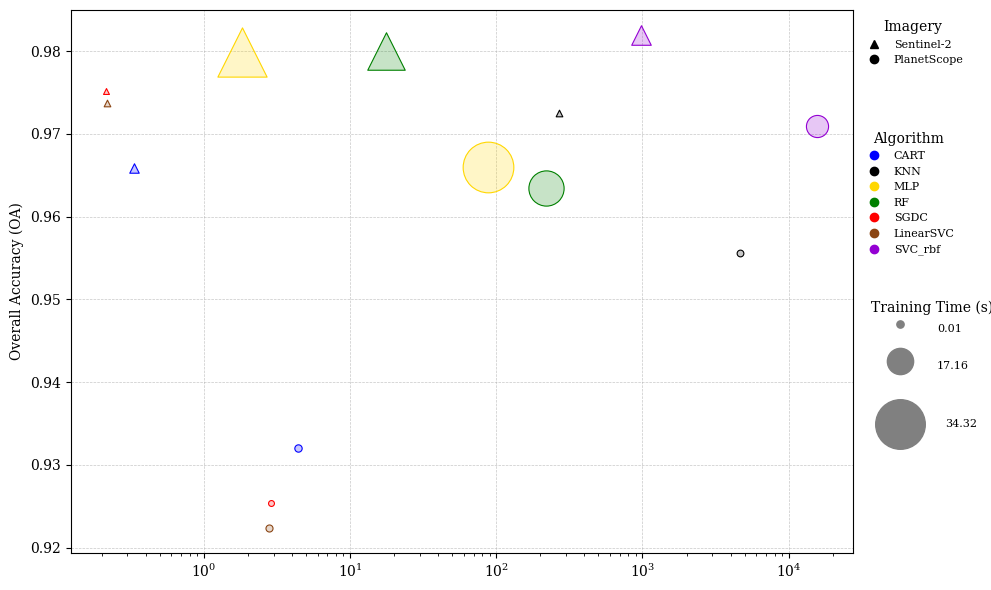

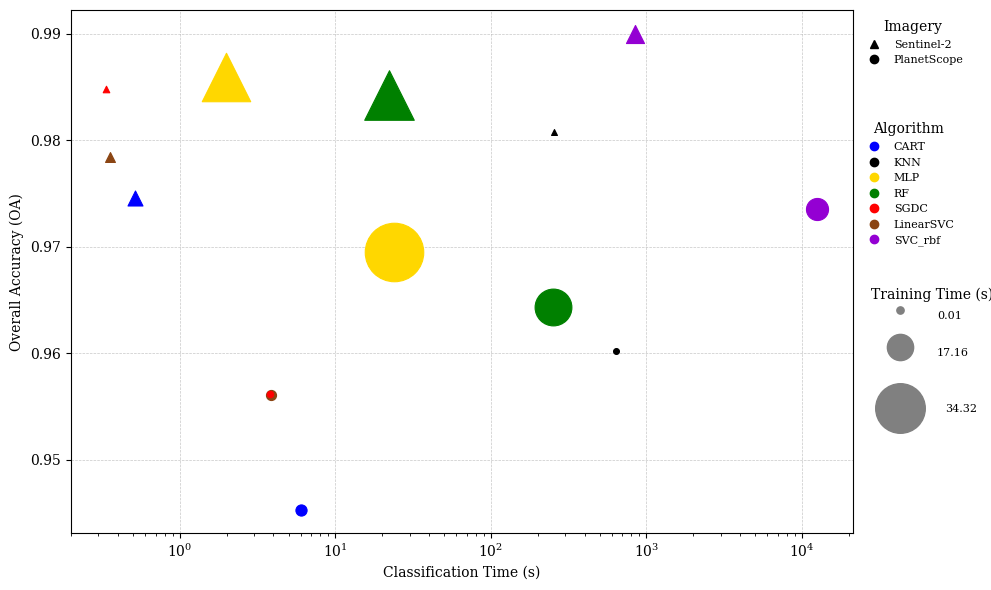

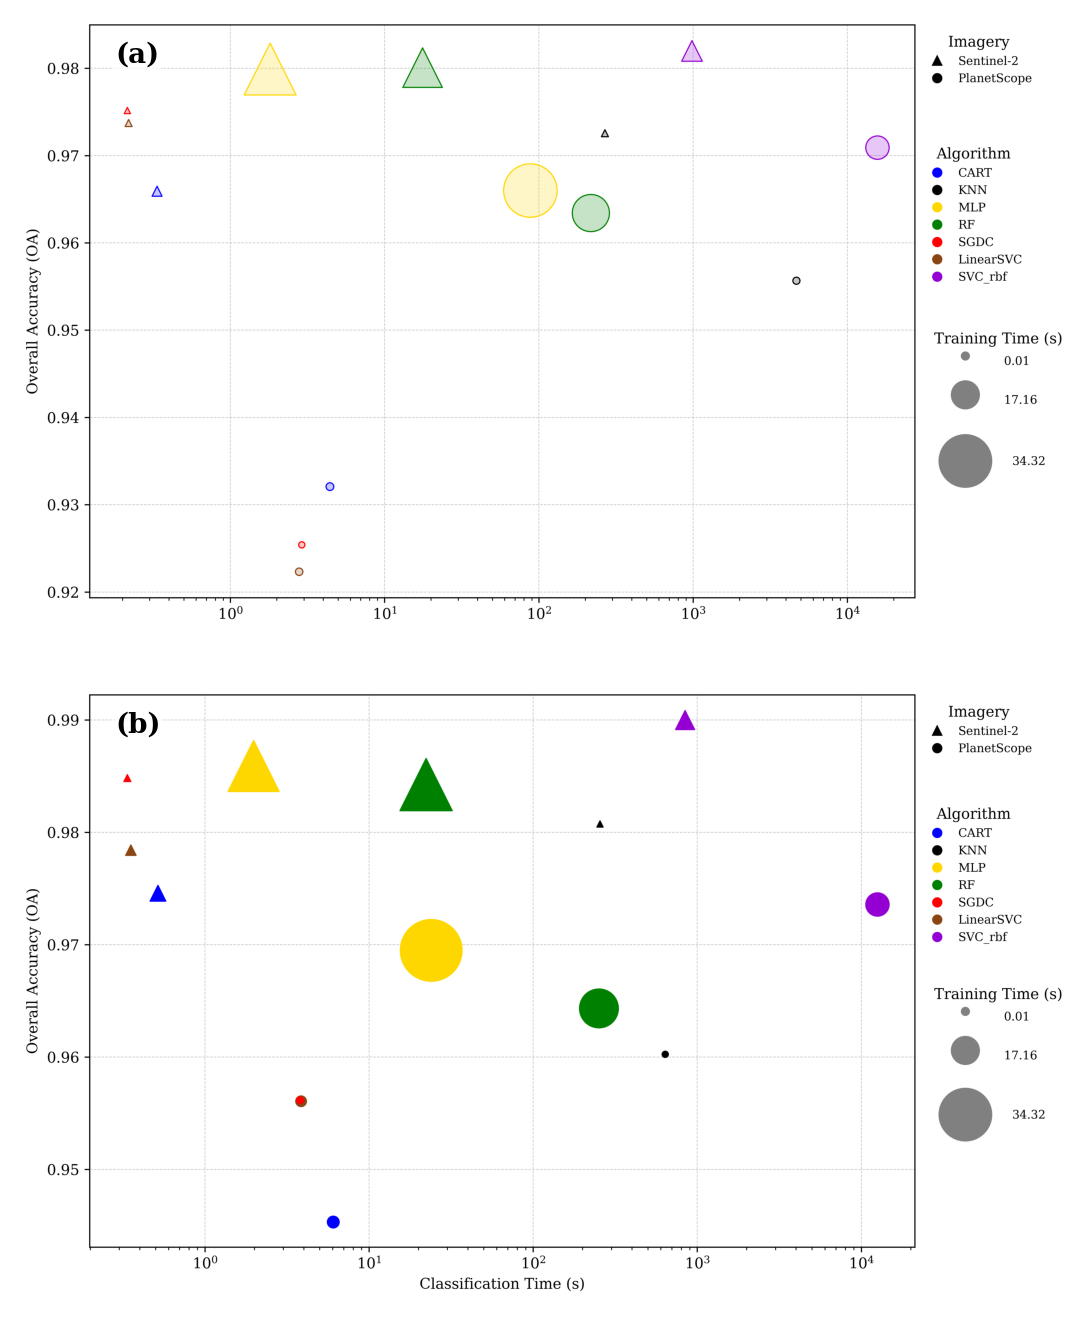

Figura salva: fig_appendix_scatter_4_and_all.png


In [20]:
plot_scatter_from_mode(plot_data, mode="4", output_name="FigRes4Bands.png", show_xlabel=False,bands=False)
plot_scatter_from_mode(plot_data, mode="all", output_name="FigResall.png",bands=False)

img_4_path = Path("FigRes4Bands.png")
img_all_path = Path("FigResall.png")
if not img_4_path.exists() or not img_all_path.exists():
    raise FileNotFoundError("Nao encontrei FigRes4Bands.png e/ou FigResall.png apos gerar os graficos.")

img_4 = mpimg.imread(img_4_path)
img_all = mpimg.imread(img_all_path)

fig2, (ax_top, ax_bottom) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12.0, 13.5),
    gridspec_kw={"hspace": 0.06},
)
fig2.subplots_adjust(left=0.02, right=0.985, top=0.985, bottom=0.02, hspace=0.06)

ax_top.imshow(img_4)
ax_top.axis("off")
ax_top.text(
    0.10, 0.95, "(a)",
    transform=ax_top.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    color="black",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    zorder=30,
)

ax_bottom.imshow(img_all)
ax_bottom.axis("off")
ax_bottom.text(
    0.10, 0.95, "(b)",
    transform=ax_bottom.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    color="black",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    zorder=30,
)

output_name_scatter = "fig_appendix_scatter_4_and_all"
fig2.savefig(f"{output_name_scatter}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
plt.show()
print(f"Figura salva: {output_name_scatter}.png")